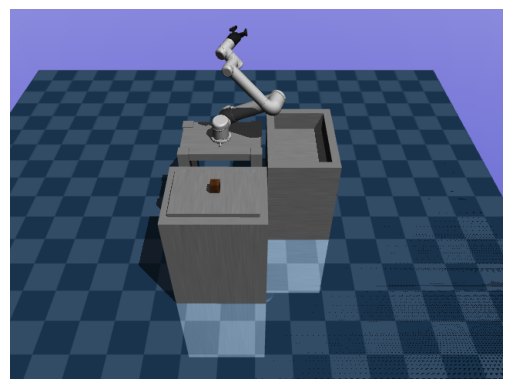

Warm xs: 1500001
Positions dict: {'shoulder_pan_joint': 0.8292299494759633, 'shoulder_lift_joint': -0.0255291815358668, 'elbow_joint': 0.5376660290774593, 'wrist_1_joint': -0.5503275881596084, 'wrist_2_joint': -1.8988886430377567, 'wrist_3_joint': -0.9243395354653081, 'base_to_lik': 1.1520283381094187}


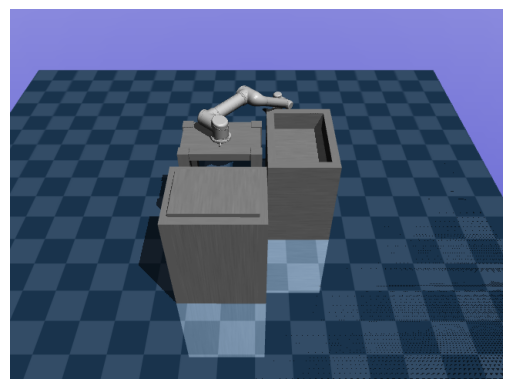

In [1]:
from pathlib import Path
import mujoco
import numpy as np
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPDController import RobotPDController
import matplotlib.pyplot as plt

MODEL_PATH = Path.cwd().parent / "models" / "UR5gripper_2_finger_KKI.xml"
MujModel = RobotMujocoModel(MODEL_PATH)

controller = RobotPDController(MujModel, kp=50.0, kd=25.0)
# controller = RobotPDController(MujModel)

q0 = MujModel.actuated_joint_positions
v0 = np.zeros_like(MujModel.v_indices())
x0 = np.concatenate([list(q0.values()), list(v0)])

q_target = MujModel.random_actuated_q()
# print("Target joint positions:", q_target)
# q_target = {'shoulder_pan_joint': 0.876943014441486, 'shoulder_lift_joint': -1.444413665177651, 'elbow_joint': -0.005655999809186074, 'wrist_1_joint': 0.6457190588893957, 'wrist_2_joint': -3.0945858658471095, 'wrist_3_joint': 0.06757263577653694, 'base_to_lik': 0.5046540468473186}
v_target = np.zeros_like(MujModel.v_indices())
target = np.concatenate([list(q_target.values()), list(v_target)])
MujModel.joint_positions = q_target
MujModel.snapshot(plot=True)
MujModel.joint_positions = q0
# MujModel.snapshot(plot=True)

# print("Initial state (x0):", x0)
# print("Target state (x):", target)
warm_xs, warm_us = controller.compute_control(x0, target, 3000)
# print("Computed control:", warm_us)
# print("Computed states:", warm_xs)
print(f"Warm xs: {len(warm_xs)}")

    
for x in warm_xs[-1:]:
    # print("State:", x)
    # print("Joint positions:", x[:MujModel.q_indices().size])
    positions_dict = {name: float(x[idx]) for name, idx in zip(MujModel.actuated_joint_names, MujModel.q_indices())}
    print("Positions dict:", positions_dict)
    MujModel.joint_positions = positions_dict
    MujModel.snapshot(plot=True)


In [2]:
import time
import mujoco
import mujoco.viewer
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

render_mode = "window"  # choose: "inline" or "window"
# render_mode = "inline"  # choose: "inline" or "window"
MujModel.reset()  # reset to initial state (q0, v0)


if render_mode == "window":
    with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
        for _ in range(len(warm_us)):
            u_cmd = warm_us[_]
            MujModel.data.ctrl[:] = u_cmd
            mujoco.mj_step(MujModel.model, MujModel.data)
            viewer.sync()
            time.sleep(MujModel.model.opt.timestep)
elif render_mode == "inline":
    renderer = mujoco.Renderer(MujModel.model, height=480, width=640)
    frames = []
    for _ in range(len(warm_us)):
        u_cmd = warm_us[_]
        MujModel.data.ctrl[:] = u_cmd
        mujoco.mj_step(MujModel.model, MujModel.data)
        renderer.update_scene(MujModel.data)
        frames.append(renderer.render().copy())
        time.sleep(MujModel.model.opt.timestep)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axis("off")
    im = ax.imshow(frames[0])

    def _update(frame_idx):
        im.set_data(frames[frame_idx])
        return (im,)

    ani = animation.FuncAnimation(fig, _update, frames=len(frames), interval=30, blit=True)
    plt.close(fig)
    display(HTML(ani.to_jshtml()))

In [ ]:
import logging
from pathlib import Path
import time
import numpy as np
import mujoco
import mujoco.viewer
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPDController import RobotPDController
from optimal.utils import setup_strict_logging

setup_strict_logging(_level=logging.INFO)
VISUALIZE_WARM_START = True
# MODEL_PATH = Path.cwd().parent / "models" / "UR5gripper_2_finger_KKI.xml"
MODEL_PATH = Path.cwd().parent / "models" / "UR5_empty.xml"
MujModel = RobotMujocoModel(MODEL_PATH)
WarmStartController = RobotPDController(MujModel)
x0 = MujModel.current_state()
logging.info(f"Initial state: {np.array2string(x0, precision=4, suppress_small=True)}")

# q_target = [np.float64(-2.534909395365788), np.float64(-0.2052620169480992), np.float64(-0.6715701234164646), np.float64(0.9119147888970156), np.float64(1.8533697768029596), np.float64(1.270718240347831), np.float64(-0.7166096062697207)]
q_target = np.array(list(MujModel.random_actuated_q(ensure_feasible=True).values()))
v_target = np.zeros_like(MujModel.v_indices(), dtype=float)
x_target = np.concatenate([q_target, v_target])
MujModel.data.qpos[MujModel.q_indices()] = x_target[:MujModel.q_indices().size]
mujoco.mj_forward(MujModel.model, MujModel.data)
MujModel.snapshot(plot=True)
MujModel.reset()  # reset to initial state (q0, v0)
logging.info(f"Full target state: {np.array2string(x_target, precision=4, suppress_small=True)}")

TOTAL_TIME = 5.0 #seconds
CONTROL_DT = 0.02  # optimize at 50 Hz instead of every MuJoCo substep
N_SUBSTEPS = max(1, int(round(CONTROL_DT / MujModel.model.opt.timestep)))
HORIZON = int(TOTAL_TIME / CONTROL_DT)
warm_xs, warm_us = WarmStartController.compute_control(x0, x_target, HORIZON, CONTROL_DT)

start_wall_time = time.time()
start_sim_time = MujModel.data.time
if VISUALIZE_WARM_START:
    with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
        for u_cmd in warm_us:
            MujModel.data.ctrl[:] = u_cmd
            mujoco.mj_step(MujModel.model, MujModel.data)
            viewer.sync()
end_sim_time = MujModel.data.time
print(f"Warm start control simulated time: {end_sim_time - start_sim_time:.4f} seconds")
end_wall_time = time.time()
print(f"Warm start control execution time: {end_wall_time - start_wall_time:.4f} seconds")
MujModel.snapshot(plot=True)

x_end = MujModel.current_state()
q_err = np.linalg.norm(x_end[:MujModel.q_indices().size] - x_target[:MujModel.q_indices().size])
logging.info(f"Target positions: {np.array2string(x_target[:MujModel.q_indices().size], precision=4, suppress_small=True)}")
logging.info(f"Final positions after warm start control: {np.array2string(x_end[:MujModel.q_indices().size], precision=4, suppress_small=True)}")
logging.info(f"Target velocities: {np.array2string(x_target[MujModel.q_indices().size:], precision=4, suppress_small=True)}")
logging.info(f"Final velocities after warm start control: {np.array2string(x_end[MujModel.q_indices().size:], precision=4, suppress_small=True)}")
logging.info(f"Difference between final state and target state: {np.array2string(x_target - x_end, precision=4, suppress_small=True)}")
logging.info(f"last control input: {np.array2string(warm_us[-1], precision=4, suppress_small=True)}")
logging.info(f"Position error norm after warm start control: {q_err:.6f}")